# Project 3

### Import Packages

In [1]:
# Let us import the important packages to be used here. 
# by now you should be able to recognize the packages and their general usage

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all our plots
# seaborn styles make plots look more professional with minimal effort
sns.set_style('whitegrid')
sns.set_palette('deep')


### Load the data

In [2]:
#### Load in the data in csv

 # importing the national household travel survey

nhts_data = pd.read_csv('NHTS.csv') 
ngsim_data = pd.read_csv('NGSIM.csv')


## Bar Chart

<Figure size 1000x600 with 0 Axes>

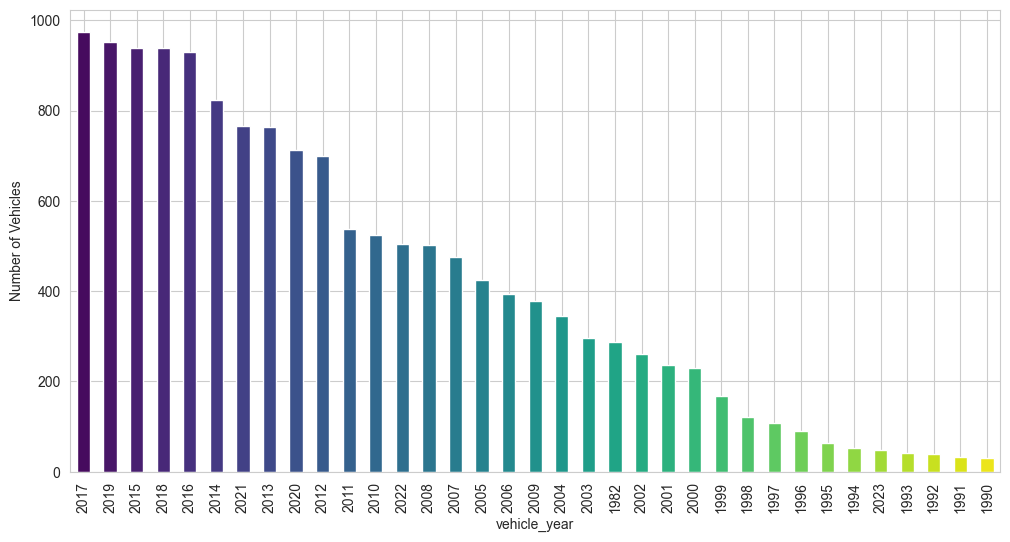

In [3]:
# A bar chart comparing categories within a specific variable 

input1 = 'vehicle_year'

fuel_counts = nhts_data[input1].value_counts().dropna()

plt.figure(figsize = (10,6))

## Step 1: count the number of vehicles by fuel type
# hint: use .value_counts()

plt.figure(figsize = (12,6))

fuel_counts.plot(kind = 'bar', color = sns.color_palette('viridis', len(fuel_counts)))

## Step 2: create the bar plot

plt.xlabel(input1)
plt.ylabel('Number of Vehicles')

## Step 3: add labels and customization


## Step 4: show the plot
plt.show()

## Histogram

Text(0, 0.5, 'Count')

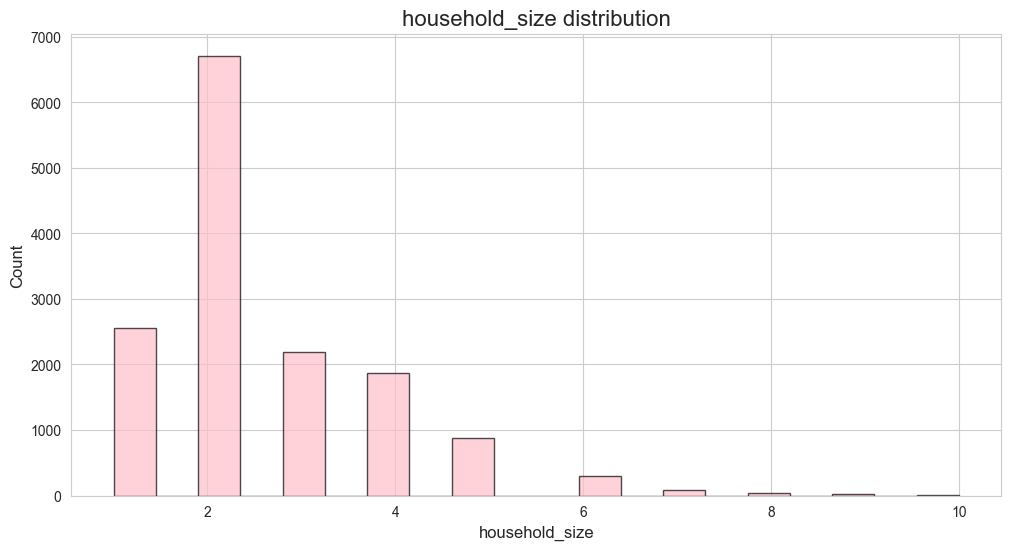

In [12]:
# A histogram showing the distribution of a specific variable 

##Let's use matplotlib to create a histogram

##Tell Python you are plotting a figure and how big you want the figure to be

input2 = 'household_size'
plt.figure(figsize = (12, 6))

## Tell Python what type of plot you want. Here, .hist() creates a histogram
plt.hist(nhts_data[input2], bins = 20, edgecolor = 'black', alpha = 0.7, color = 'pink')
         

# Then let's label. You'll notice you can change the fontsize of all your labels!
plt.title(f"{input2} distribution", fontsize = 16)
plt.xlabel(input2, fontsize = 12)
plt.ylabel('Count', fontsize = 12)

## Box Plot

<Figure size 2000x1600 with 0 Axes>

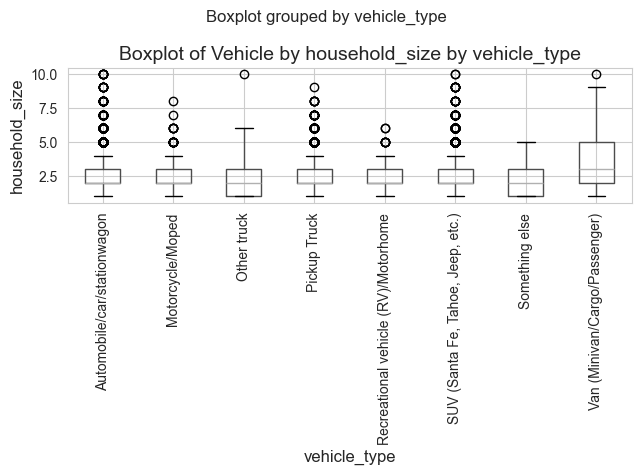

In [5]:
## Step 1: tell Python you are making a figure and what size you want the figure to be

plt.figure(figsize = (20,16))

## Step 2: call the type of plot and tell the function what variables you want to plot
input3 = 'household_size'
input4 = 'vehicle_type'
boxplot = nhts_data.boxplot(column = input3, by = input4)
## Step 3: add customization to the plot

### this line rotates your labels on the x-axis by 90 so they are easy to read

plt.xticks(rotation = 90)
### the next two lines create your axis labels

plt.xlabel(input4, fontsize = 12)
plt.ylabel(input3, fontsize = 12)
### this line gives your plot a title

plt.title(f"Boxplot of Vehicle by {input3} by {input4}", fontsize = 14)

## Step 4: tell python to show the plot
plt.tight_layout()
plt.show()


## Time Series 1

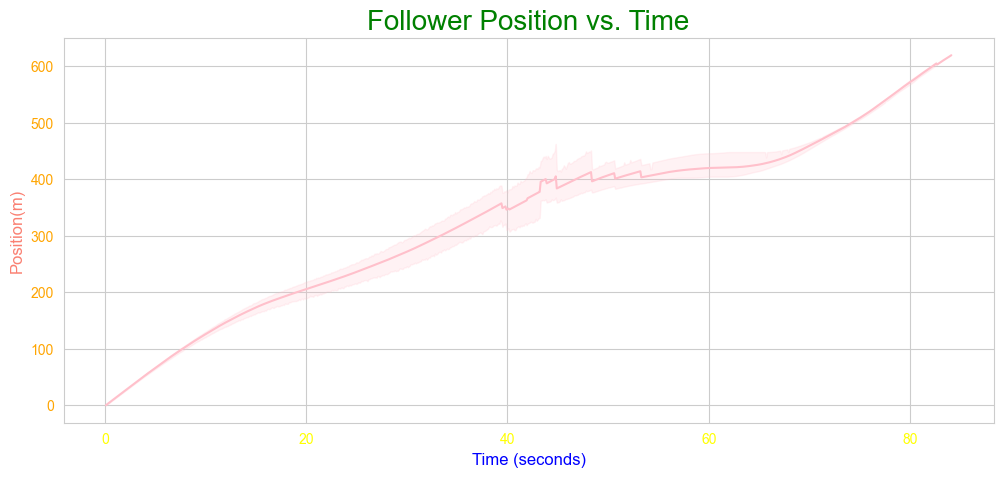

In [6]:
### Plotting Position vs Time

# replicate the above steps, but now visualize the follower_position(m) data with time 
# We are interested in analyzing the acceleration profile of the follower vehicles (follower_acc(m/s^2)) as function of time. Follow the steps we have learned from previous lab to do so. 
# hint we need to use the sns.lineplot 

# Step 1: tell python that you want to plot and assign a size 
plt.figure(figsize = (12, 5))

# Step 2: use sns.lineplot to create a time series plot of Time (x-axis) and follower_acc(m/s^2) (y-axis)
sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['follower_position(m)'], color = 'pink')

# Step 3: add customizations

plt.xlabel('Time (seconds)', fontsize = 12, color = 'blue')
plt.ylabel('Position(m)', fontsize = 12, color = 'salmon')
plt.title('Follower Position vs. Time', fontsize = 20, color = 'green')
plt.xticks(color = 'yellow')
plt.yticks(color = 'orange')
plt.show()

## Time Series 2

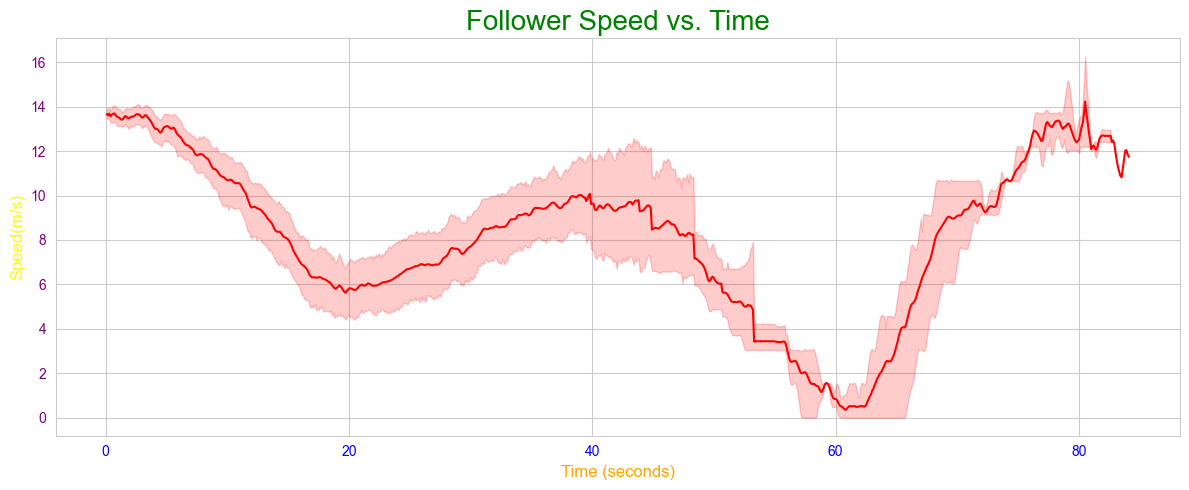

In [7]:
### Plotting Speed vs Time

# replicate the above steps, but now visualize the follower_speed(m/s) data with time 

# We are interested in analyzing the acceleration profile of the follower vehicles (follower_acc(m/s^2)) as function of time. Follow the steps we have learned from previous lab to do so. 
# hint we need to use the sns.lineplot 

# Step 1: tell python that you want to plot and assign a size 
plt.figure(figsize = (12, 5))

# Step 2: use sns.lineplot to create a time series plot of Time (x-axis) and follower_acc(m/s^2) (y-axis)
sns.lineplot(x = ngsim_data['Time'], y = ngsim_data['follower_speed(m/s)'], color = 'red')

# Step 3: add customizations

plt.xlabel('Time (seconds)', fontsize = 12, color = 'orange')
plt.ylabel('Speed(m/s)', fontsize = 12, color = 'yellow')
plt.title('Follower Speed vs. Time', fontsize = 20, color = 'green')
plt.xticks(color = 'blue')
plt.yticks(color = 'purple')
plt.tight_layout()
plt.show()

## IDM Simulation

In [8]:
def idm_acceleration(v, s, delta_v, v0, s0, T, a, b, delta):

    s_star = s0 + v * T + (v * delta_v) / (2 * np.sqrt(a * b))

    # Ensure minimum gap
    s_star = np.maximum(s_star, s0)

    acceleration = a * (  1 - (v / v0) ** delta - (s_star / max(s, 1e-6)) ** 2)
    return acceleration

# Select a trajectory pair

trajectory_number = 1 
data_subset = ngsim_data[ngsim_data['trajectory_number'] == trajectory_number].reset_index(drop=True)
# Extract the leader's position and speed over time

time_data = data_subset['Time'].values

leader_position = data_subset['leader_position(m)'].values
leader_speed = data_subset['leader_speed(m/s)'].values

# Identifying the time step in our data

dt = 0.1 #every 0.1 seconds, I willcalcualte acceleration value 




In [9]:
### Set the IDM parameters
v0 = 30    # desired velocity (m/s)
s0 = 2     # minimum spacing (m)
T = 1.5    # desired time headway (s)
a_param = 1.0    # maximum acceleration (m/s^2)  
b = 1.5    # comfortable deceleration (m/s^2)
delta = 4  # acceleration exponent

# Initialize arrays to store simulation results
n_steps = len(time_data)         # number of simulation steps we will take, which will be equal to the length of the trajectory data
sim_position = np.zeros(n_steps)         # simulated follower position; we will create a vector with all zeroes  as a start
sim_speed = np.zeros(n_steps)         # simulated follower speed; we will create a vector with all zeroes  as a start
sim_acc = np.zeros(n_steps)         # simulated follower acceleration; we will create a vector with all zeroes  as a start



# Start at the real follower's initial state
        #this makes the starting value [0] same as the follower vehicle position
        #this makes the starting value [0] same as the follower vehicle speed

sim_position[0] = data_subset['follower_position(m)'].values[0]
sim_speed[0] = data_subset['follower_speed(m/s)'].values[0]


In [10]:
# Run the IDM simulation
# We loop through each time step and calculate:
#   1. The gap between the leader and follower
#   2. The speed difference between the two vehicles
#   3. The IDM acceleration
#   4. The updated speed using: new_speed = old_speed + acceleration * dt
#   5. The updated position using: new_position = old_position + speed * dt

for i in range(n_steps - 1): # we do -1 since the first element is known (remember the step above) 

    # Step 1 & 2: Calculate the gap and speed difference at this time step
    gap = leader_position[i] - sim_position[i]
    delta_v = sim_speed[i]-leader_speed[i]
    
    # Step 3: Use the IDM function to calculate acceleration
    sim_acc[i] = idm_acceleration(sim_speed[i], gap, delta_v, v0, s0, T, a_param, b, delta)
    
    # Step 4 & 5: Update speed and position for the next time step
    sim_speed[i+1] = max(sim_speed[i] + sim_acc[i] * dt, 0) # this updates my speed for next iteration based on physics equation of motion
    sim_position[i+1] = sim_position[i] + sim_speed[i] * dt
    #print(i)
    
print("Simulation complete!")

Simulation complete!


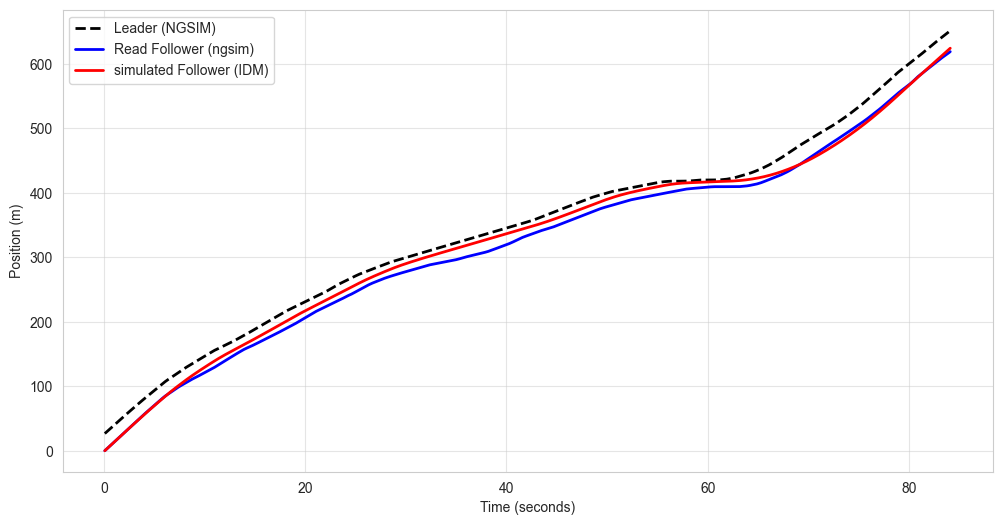

In [11]:
# Plot 1: Position vs Time — Comparing leader, real follower, and simulated follower

plt.figure(figsize = (12,6))
plt.plot(time_data, leader_position, 'k--', linewidth = 2, label = 'Leader (NGSIM)')
plt.plot(time_data, data_subset['follower_position(m)'].values, 'b-', linewidth = 2, label = 'Read Follower (ngsim)')
plt.plot(time_data, sim_position, 'r-', linewidth = 2, label = 'simulated Follower (IDM)')
plt.xlabel('Time (seconds)')
plt.ylabel('Position (m)')
plt.legend()
plt.grid(True, alpha = 0.5)
plt.show()